# Evaluation of Wind Forecasting Models Against ERA5 and Station Observations, 2016–2022 (Extended to +72h)

## 1. Aim and Analysis Questions

This notebook evaluates wind speed forecasts from **FCN3**, **GraphCast**, and **HRES** for 12
meteorological stations over 2016–2022. Unlike the companion `model_comparison_analysis.ipynb`
(lead times +6h to +24h), this notebook uses the extended `_72h` forecast runs and covers the
full 6-hourly lead ladder from **+6h to +72h** (13 lead times). ERA5 is used as the
input/reference dataset, and station-based wind measurements are used as the main observational
benchmark.

The analysis focuses on:

1. Overall model performance across all stations and years.
2. Performance differences between models.
3. Performance variation by forecast lead time, out to +72h.
4. Station-wise and year-wise error patterns.
5. Important high-wind cases at selected coastal stations.

Full evaluation period: **2016–2022**.

## 2. Data Description

### 2.1 Forecast datasets

The evaluated forecast models are **FCN3**, **GraphCast**, and **HRES**. All three are matched to
the nearest 0.25° grid cell for each of the 12 stations and evaluated at lead times
+6h to +72h in 6-hour increments (6, 12, 18, 24, 30, 36, 42, 48, 54, 60, 66, 72 h — 13 lead times total), using the extended
`FCN3_72h` / `GraphCast_72h` forecast runs (`NSTEPS_LONG=12`, see `config.py`).

- FCN3 and GraphCast are run here at the **same cadence**: daily 00:00 UTC initialization only.
  GraphCast is natively a 6-hourly model, but is restricted to 00:00 UTC here so both ML models
  are compared against HRES on an identical set of verification events (see
  `graphcast_case_study_analysis.ipynb` for the full 6-hourly GraphCast evaluation).
- HRES is ECMWF's operational forecast, natively initialized at 00:00 **and** 12:00 UTC. Both
  init cycles are kept in this notebook (HRES is not restricted to 00:00 UTC), so HRES has more
  matched samples per lead time than FCN3/GraphCast — this is visible in the data availability
  section below.

### 2.2 ERA5 data

ERA5 is used as the input/reference atmospheric dataset. It provides gridded (0.25°), 6-hourly
reanalysis 10 m wind fields and is used for comparison with both model forecasts and station
observations.

### 2.3 Station observations

Station observations (hourly, from the Frost API) are used as the main ground-truth benchmark
for local wind conditions. These measurements represent near-surface wind at specific point
locations and may capture local terrain and coastal effects that are not fully resolved by
gridded forecast products at 0.25° resolution.

In [6]:
import warnings
warnings.filterwarnings('ignore')

import nest_asyncio
nest_asyncio.apply()

import numpy as np
import pandas as pd
import xarray as xr
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from IPython.display import display

# ── Paths ─────────────────────────────────────────────────────────────────────
ERA5_DIR  = Path('/cluster/work/projects/nn8106k/siyan/era5_6h')
FC_ROOT   = Path('/cluster/work/projects/nn8106k/siyan/WF-experiments/case-study/forecasts/FCN3_72h')
GC_ROOT   = Path('/cluster/work/projects/nn8106k/siyan/WF-experiments/case-study/forecasts/GraphCast_72h')
OBS_DIR   = Path('/cluster/home/siyan/github/WF-experiments/experiments/outputs/wind_obs')
OUT_ROOT  = Path('/cluster/work/projects/nn8106k/siyan/WF-experiments/case-study')
FIG_DIR   = OUT_ROOT / 'figures_72h'
FIG_DIR.mkdir(parents=True, exist_ok=True)

HRES_ZARR = Path('/cluster/work/projects/nn8106k/siyan/weatherbench2_forecasts/hres/0p25/2016-2022-0012-1440x721.zarr')

CSV_MASTER   = OUT_ROOT / 'master_forecast_dataset_72h.csv'
CSV_ERA5_OBS = OUT_ROOT / 'era5_vs_obs_dataset.csv'
CSV_HW_MERGED = OUT_ROOT / 'merged_fcn3_graphcast_hres_obs_all_years_72h.csv'

# ── Experiment config ──────────────────────────────────────────────────────────
YEARS         = [2016, 2017, 2018, 2019, 2020, 2021, 2022]
LEAD_HOURS    = [6, 12, 18, 24, 30, 36, 42, 48, 54, 60, 66, 72]
HIGH_WIND_THR = 10.8   # m/s — 9-12 m/s bin (near-gale/gale, Beaufort 9-12)

MODEL_ORDER = ['FCN3', 'GraphCast', 'HRES']
REF_ORDER   = ['obs', 'era5']
METRICS     = ['RMSE', 'MAE', 'Bias', 'nRMSE', 'nBias', 'Corr']

STATIONS = [
    {'id': 'SN88690', 'name': 'Hekkingen Fyr',     'lat': 69.6005, 'lon': 17.8317, 'county': 'Troms',    'obs_base': 'SN88690_Hekkingen_Fyr'},
    {'id': 'SN90490', 'name': 'Tromsø-Langnes',     'lat': 69.6767, 'lon': 18.9133, 'county': 'Troms',    'obs_base': 'SN90490_Tromsoe_Langnes'},
    {'id': 'SN90760', 'name': 'Fakken',             'lat': 70.1043, 'lon': 20.1145, 'county': 'Troms',    'obs_base': 'SN90760_Fakken'},
    {'id': 'SN90800', 'name': 'Torsvåg Fyr',        'lat': 70.2450, 'lon': 19.5000, 'county': 'Troms',    'obs_base': 'SN90800_Torsvag_Fyr'},
    {'id': 'SN90720', 'name': 'Måsvik',             'lat': 69.9900, 'lon': 18.6940, 'county': 'Troms',    'obs_base': 'SN90720_Masvik'},
    {'id': 'SN91740', 'name': 'Sørkjosen Lufthavn', 'lat': 69.7900, 'lon': 20.9520, 'county': 'Troms',    'obs_base': 'SN91740_Sorkjosen_Lufthavn'},
    {'id': 'SN89350', 'name': 'Bardufoss',          'lat': 69.0580, 'lon': 18.5440, 'county': 'Troms',    'obs_base': 'SN89350_Bardufoss'},
    {'id': 'SN87110', 'name': 'Andøya',             'lat': 69.3070, 'lon': 16.1310, 'county': 'Nordland', 'obs_base': 'SN87110_Andoya'},
    {'id': 'SN85380', 'name': 'Skrova Fyr',         'lat': 68.1530, 'lon': 14.6490, 'county': 'Nordland', 'obs_base': 'SN85380_Skrova_Fyr'},
    {'id': 'SN94500', 'name': 'Fruholmen Fyr',      'lat': 71.0940, 'lon': 23.9840, 'county': 'Finnmark', 'obs_base': 'SN94500_Fruholmen_Fyr'},
    {'id': 'SN96400', 'name': 'Slettnes Fyr',       'lat': 71.0890, 'lon': 28.2170, 'county': 'Finnmark', 'obs_base': 'SN96400_Slettnes_Fyr'},
    {'id': 'SN95350', 'name': 'Banak',              'lat': 70.0600, 'lon': 24.9790, 'county': 'Finnmark', 'obs_base': 'SN95350_Banak'},
]
STATIONS_BY_ID = {s['id']: s for s in STATIONS}
STATION_ORDER  = [s['id'] for s in STATIONS]
STATION_LABELS = [s['name'] for s in STATIONS]

# Coastal lighthouse ("Fyr") stations — used to highlight high-wind cases at
# exposed coastal sites in the last section.
COASTAL_STATIONS = [s['id'] for s in STATIONS if 'Fyr' in s['name']]

# Stations flagged in project notes as sitting in complex coastal terrain,
# where nearest-gridpoint matching to the 0.25° model grid is least reliable.
COMPLEX_TERRAIN_STATIONS = ['SN88690', 'SN90490']  # Hekkingen Fyr, Tromsø-Langnes

CLR = {
    'FCN3':      '#2196F3',  # blue
    'GraphCast': '#4CAF50',  # green
    'HRES':      '#FF9800',  # orange
    'ERA5':      '#8E44AD',
    'Obs':       '#607D8B',
}
COUNTY_CLR = {'Troms': '#2980B9', 'Nordland': '#E74C3C', 'Finnmark': '#27AE60'}

print(f'Config loaded. YEARS={YEARS}  LEAD_HOURS={LEAD_HOURS}  HIGH_WIND_THR={HIGH_WIND_THR} m/s')

Config loaded. YEARS=[2016, 2017, 2018, 2019, 2020, 2021, 2022]  LEAD_HOURS=[6, 12, 18, 24, 30, 36, 42, 48, 54, 60, 66, 72]  HIGH_WIND_THR=10.8 m/s


## 3. Station Metadata and Map

12 stations across Troms, Nordland and Finnmark, all in distinct 0.25° grid cells.

**Data gap:** elevation and a formal terrain classification are not currently available for
these stations — the table below shows what is tracked (ID, name, coordinates, region). As a
rough proxy, stations named "*Fyr*" are coastal lighthouses (see `COASTAL_STATIONS`); the rest
are airports or inland/town sites.

Two stations are flagged in project notes as sitting in complex coastal terrain where
nearest-gridpoint matching to the model grid should be inspected carefully: **Tromsø-Langnes**
and **Hekkingen Fyr** (highlighted with a red ring on the map).

In [7]:
import os
from pathlib import Path

for line in Path("/cluster/home/siyan/github/WF-experiments/.env").read_text().splitlines():
    if line.strip() and not line.startswith("#") and "=" in line:
        k, v = line.split("=", 1)
        os.environ.setdefault(k.strip(), v.strip())


In [8]:
station_table = pd.DataFrame([
    {'ID': s['id'], 'Name': s['name'], 'Latitude': s['lat'], 'Longitude': s['lon'],
     'Region': s['county'],
     'Coastal (Fyr)': 'Yes' if s['id'] in COASTAL_STATIONS else '',
     'Complex terrain flag': 'Yes' if s['id'] in COMPLEX_TERRAIN_STATIONS else ''}
    for s in STATIONS
])
display(station_table)

,ID,Name,Latitude,Longitude,Region,Coastal (Fyr),Complex terrain flag
0,SN88690,Hekkingen Fyr,69.6005,17.8317,Troms,Yes,Yes
1,SN90490,Tromsø-Langnes,69.6767,18.9133,Troms,,Yes
2,SN90760,Fakken,70.1043,20.1145,Troms,,
3,SN90800,Torsvåg Fyr,70.2450,19.5000,Troms,Yes,
4,SN90720,Måsvik,69.9900,18.6940,Troms,,
5,SN91740,Sørkjosen Lufthavn,69.7900,20.9520,Troms,,
6,SN89350,Bardufoss,69.0580,18.5440,Troms,,
7,SN87110,Andøya,69.3070,16.1310,Nordland,,
8,SN85380,Skrova Fyr,68.1530,14.6490,Nordland,Yes,
9,SN94500,Fruholmen Fyr,71.0940,23.9840,Finnmark,Yes,


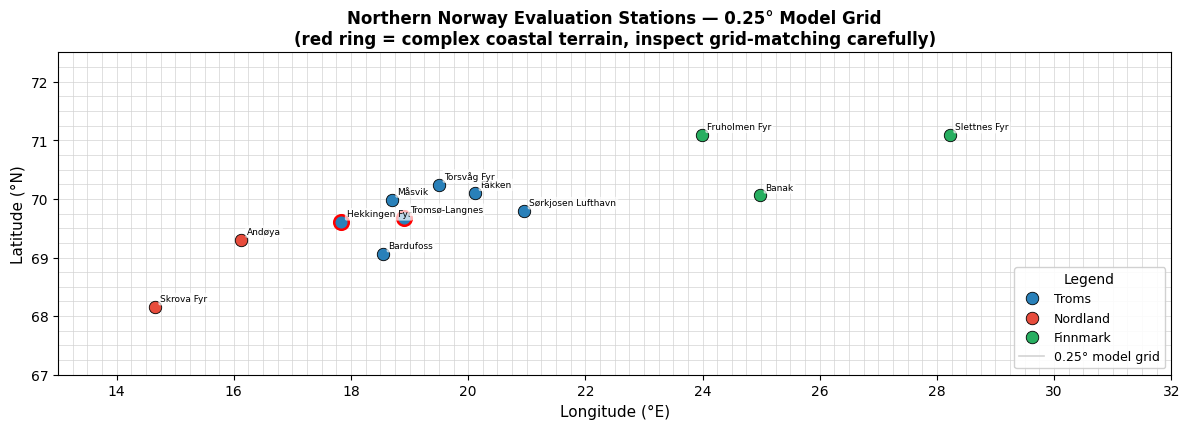

In [9]:
lon_min, lon_max, lat_min, lat_max = 13.0, 32.0, 67.0, 72.5
fig, ax = plt.subplots(figsize=(12, 7))
res = 0.25
for lon in np.arange(np.ceil(lon_min / res) * res, lon_max + res, res):
    ax.axvline(lon, color='lightgray', lw=0.5, zorder=1)
for lat in np.arange(np.ceil(lat_min / res) * res, lat_max + res, res):
    ax.axhline(lat, color='lightgray', lw=0.5, zorder=1)

for st in STATIONS:
    clr = COUNTY_CLR[st['county']]
    is_flagged = st['id'] in COMPLEX_TERRAIN_STATIONS
    ax.scatter(st['lon'], st['lat'], color=clr, s=110 if is_flagged else 80, zorder=4,
               edgecolors='red' if is_flagged else 'black',
               linewidths=1.8 if is_flagged else 0.6)
    ax.annotate(st['name'], xy=(st['lon'], st['lat']),
                xytext=(4, 4), textcoords='offset points', fontsize=6.5, zorder=5,
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7, edgecolor='none'))

ax.set_xlim(lon_min, lon_max); ax.set_ylim(lat_min, lat_max)
ax.set_xlabel('Longitude (°E)', fontsize=11); ax.set_ylabel('Latitude (°N)', fontsize=11)
ax.set_title('Northern Norway Evaluation Stations — 0.25° Model Grid\n(red ring = complex coastal terrain, inspect grid-matching carefully)',
             fontsize=12, fontweight='bold')
ax.xaxis.set_major_locator(mticker.MultipleLocator(2))
ax.yaxis.set_major_locator(mticker.MultipleLocator(1))

county_order = list(dict.fromkeys(st['county'] for st in STATIONS))
county_handles = [plt.Line2D([0], [0], marker='o', linestyle='none', markerfacecolor=COUNTY_CLR[c],
                              markeredgecolor='black', markeredgewidth=0.6, markersize=9, label=c)
                   for c in county_order]
grid_handle = plt.Line2D([0], [0], color='lightgray', lw=1.2, label='0.25° model grid')
ax.legend(handles=county_handles + [grid_handle], title='Legend', fontsize=9, loc='lower right', framealpha=0.9)
ax.set_aspect('equal', adjustable='box'); ax.grid(False)
plt.tight_layout()
plt.savefig(FIG_DIR / 'station_map_grid.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
import os
import requests
from pathlib import Path

OUT_DIR = Path("../outputs/map_data")
OUT_DIR.mkdir(exist_ok=True)

API_KEY = os.environ["OPENTOPOGRAPHY_API_KEY"]

# Bounding box covering all 12 stations across Northern Norway
south = 67.5
north = 71.7
west  = 13.0
east  = 29.5

url = "https://portal.opentopography.org/API/globaldem"

params = {
    "demtype": "COP90",          # Copernicus DEM GLO-90 (90 m) — ~9x smaller than COP30
    "south": south,
    "north": north,
    "west": west,
    "east": east,
    "outputFormat": "GTiff",
    "API_Key": API_KEY,
}

r = requests.get(url, params=params, timeout=300)
r.raise_for_status()

out_path = OUT_DIR / "dem_northern_norway_cop90.tif"
out_path.write_bytes(r.content)

print(f"Saved: {out_path}")
print(f"File size: {out_path.stat().st_size / 1024 / 1024:.2f} MB")


Saved: ../outputs/map_data/dem_northern_norway_cop90.tif
File size: 180.58 MB


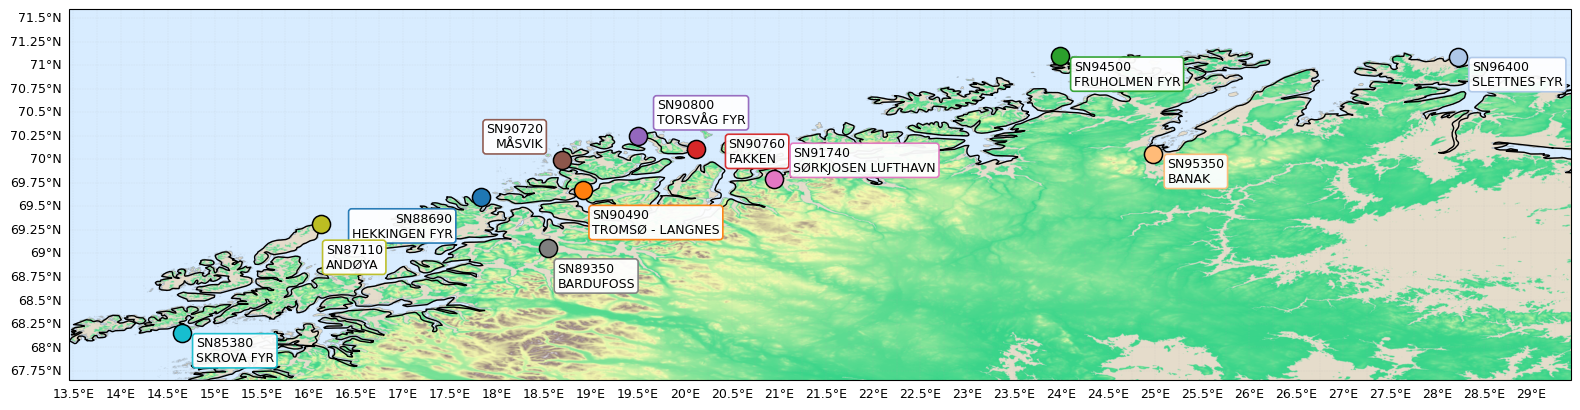

In [15]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import rasterio
import matplotlib.ticker as mticker

FIG_DIR = Path("images")
FIG_DIR.mkdir(exist_ok=True)

STATIONS = [
    {'id': 'SN88690', 'name': 'HEKKINGEN FYR',     'lat': 69.6005, 'lon': 17.8317},
    {'id': 'SN90490', 'name': 'TROMSØ - LANGNES',  'lat': 69.6767, 'lon': 18.9133},
    {'id': 'SN90760', 'name': 'FAKKEN',             'lat': 70.1043, 'lon': 20.1145},
    {'id': 'SN90800', 'name': 'TORSVÅG FYR',        'lat': 70.2450, 'lon': 19.5000},
    {'id': 'SN90720', 'name': 'MÅSVIK',             'lat': 69.9900, 'lon': 18.6940},
    {'id': 'SN91740', 'name': 'SØRKJOSEN LUFTHAVN', 'lat': 69.7900, 'lon': 20.9520},
    {'id': 'SN89350', 'name': 'BARDUFOSS',          'lat': 69.0580, 'lon': 18.5440},
    {'id': 'SN87110', 'name': 'ANDØYA',             'lat': 69.3070, 'lon': 16.1310},
    {'id': 'SN85380', 'name': 'SKROVA FYR',         'lat': 68.1530, 'lon': 14.6490},
    {'id': 'SN94500', 'name': 'FRUHOLMEN FYR',      'lat': 71.0940, 'lon': 23.9840},
    {'id': 'SN96400', 'name': 'SLETTNES FYR',       'lat': 71.0890, 'lon': 28.2170},
    {'id': 'SN95350', 'name': 'BANAK',              'lat': 70.0600, 'lon': 24.9790},
]

station_colors = {
    'SN88690': '#1f77b4',
    'SN90490': '#ff7f0e',
    'SN90760': '#d62728',
    'SN90800': '#9467bd',
    'SN90720': '#8c564b',
    'SN91740': '#e377c2',
    'SN89350': '#7f7f7f',
    'SN87110': '#bcbd22',
    'SN85380': '#17becf',
    'SN94500': '#2ca02c',
    'SN96400': '#aec7e8',
    'SN95350': '#ffbb78',
}

# custom label offsets to avoid overlap in the crowded Tromso cluster
label_cfg = {
    'SN90800': {'dx': 0.20,  'dy': 0.10,  'ha': 'left',  'va': 'bottom'},   # TORSVAG FYR - up-right
    'SN90760': {'dx': 0.35,  'dy': -0.02, 'ha': 'left',  'va': 'center'},  # FAKKEN - far right
    'SN90720': {'dx': -0.20, 'dy': 0.10,  'ha': 'right', 'va': 'bottom'},  # MASVIK - up-left
    'SN90490': {'dx': 0.10,  'dy': -0.20, 'ha': 'left',  'va': 'top'},     # TROMSO-LANGNES - down-right
    'SN88690': {'dx': -0.30, 'dy': -0.16, 'ha': 'right', 'va': 'top'},     # HEKKINGEN FYR - down-left
    'SN87110': {'dx': 0.05,  'dy': -0.20, 'ha': 'left',  'va': 'top'},     # ANDOYA - down
    'SN89350': {'dx': 0.10,  'dy': -0.15, 'ha': 'left',  'va': 'top'},     # BARDUFOSS - down
    'SN91740': {'dx': 0.20,  'dy': 0.05,  'ha': 'left',  'va': 'bottom'},  # SORKJOSEN LUFTHAVN - up-right
}

dem_path = "../outputs/map_data/dem_northern_norway_cop90.tif"

lats = [s['lat'] for s in STATIONS]
lons = [s['lon'] for s in STATIONS]

fig = plt.figure(figsize=(16, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.set_extent(
    [min(lons) - 1.2, max(lons) + 1.2, min(lats) - 0.5, max(lats) + 0.5],
    crs=ccrs.PlateCarree()
)

ocean_color = "#d8ecff"
ax.set_facecolor(ocean_color)
ax.add_feature(cfeature.OCEAN, facecolor=ocean_color, edgecolor="none", zorder=0)

with rasterio.open(dem_path) as src:
    dem = src.read(1).astype(float)
    bounds = src.bounds
    if src.nodata is not None:
        dem[dem == src.nodata] = np.nan
    dem[dem <= 0] = np.nan

    base = plt.get_cmap("terrain")
    colors = base(np.linspace(0.16, 1.0, 256))
    low_color = np.array([0.92, 0.85, 0.74, 1.0])
    colors[:30] = low_color
    cmap = LinearSegmentedColormap.from_list("terrain_soft_low", colors)
    cmap.set_bad(alpha=0)

    ax.imshow(
        dem,
        origin="upper",
        extent=[bounds.left, bounds.right, bounds.bottom, bounds.top],
        transform=ccrs.PlateCarree(),
        cmap=cmap,
        alpha=0.78,
        interpolation="bilinear",
        zorder=1
    )

ax.add_feature(cfeature.COASTLINE, linewidth=1.0, edgecolor="black", zorder=3)

for s in STATIONS:
    color = station_colors[s['id']]
    ax.scatter(
        s['lon'], s['lat'],
        s=170,
        color=color,
        edgecolor="black",
        linewidth=1.1,
        zorder=5,
        transform=ccrs.PlateCarree()
    )
    cfg = label_cfg.get(s['id'], {'dx': 0.15, 'dy': -0.04, 'ha': 'left', 'va': 'top'})
    ax.text(
        s['lon'] + cfg['dx'], s['lat'] + cfg['dy'],
        f"{s['id']}\n{s['name']}",
        fontsize=9,
        transform=ccrs.PlateCarree(),
        ha=cfg['ha'],
        va=cfg['va'],
        bbox=dict(
            facecolor="white",
            edgecolor=color,
            linewidth=1.2,
            alpha=0.95,
            boxstyle="round,pad=0.25"
        ),
        zorder=6
    )

gl = ax.gridlines(draw_labels=True, linewidth=0.35, alpha=0.22, linestyle="--")
gl.top_labels = False
gl.right_labels = False
gl.xlocator = mticker.MultipleLocator(0.25)
gl.ylocator = mticker.MultipleLocator(0.25)
gl.xlabel_style = {"size": 9}
gl.ylabel_style = {"size": 9}

plt.tight_layout()

plt.savefig(FIG_DIR / "station_map_all.pdf", bbox_inches="tight")
plt.savefig(FIG_DIR / "station_map_all.png", dpi=400, bbox_inches="tight")
plt.show()

## 4. Data Preprocessing

### 4.1–4.3 Load forecasts, ERA5, and station observations

Standardized per-source loaders, each returning `(station, valid_time, ...)`:

- Forecasts: `(station, valid_time, lead_h, forecast_wind)`
- ERA5: `(station, valid_time, era5_wind)`
- Station obs: `(station, valid_time, obs_wind)`

### 4.4 Time alignment

Forecasts, ERA5, and station observations are matched by **valid time**: for each forecast
initialization and lead time, the forecast valid time is compared with ERA5 and the station
observation at that same timestamp. The result is one master dataframe:

`init_time | lead_h | valid_time | station | model | forecast | era5 | obs | year`

This is the single dataframe basically everything below is computed from.

In [ ]:
def load_obs(year: int) -> pd.DataFrame:
    """Load hourly station wind speed from Frost API CSVs.
    Returns (station, valid_time, obs_wind) — one row per station-hour.
    """
    parts = []
    for st in STATIONS:
        f = OBS_DIR / f"{st['obs_base']}_{year}.csv"
        if not f.exists():
            print(f'  [obs] Missing: {f.name}')
            continue
        df = pd.read_csv(f)
        df['valid_time'] = (pd.to_datetime(df['time'], utc=True)
                              .dt.tz_convert(None))
        df['station']   = st['id']
        df['obs_wind']  = pd.to_numeric(df['wind_speed'], errors='coerce')
        parts.append(
            df[['station', 'valid_time', 'obs_wind']].dropna()
        )
    if not parts:
        return pd.DataFrame(columns=['station', 'valid_time', 'obs_wind'])
    return (pd.concat(parts, ignore_index=True)
              .sort_values('valid_time')
              .reset_index(drop=True))

In [ ]:
def load_era5(year: int) -> pd.DataFrame:
    """Extract ERA5 10m wind speed at station nearest gridpoints.
    ERA5 is 6-hourly → valid times at 00:00, 06:00, 12:00, 18:00 UTC.
    Returns (station, valid_time, era5_wind).
    """
    f = ERA5_DIR / f'era5_single_{year}.nc'
    if not f.exists():
        print(f'  [ERA5] Missing: {f.name}')
        return pd.DataFrame(columns=['station', 'valid_time', 'era5_wind'])

    ds  = xr.open_dataset(str(f))
    ws  = np.sqrt(ds['u10'] ** 2 + ds['v10'] ** 2)   # 10m wind speed
    vt  = pd.DatetimeIndex(ds['valid_time'].values)

    rows = []
    for st in STATIONS:
        ws_st = ws.sel(latitude=st['lat'], longitude=st['lon'] % 360,
                       method='nearest').values
        for t, val in zip(vt, ws_st):
            if not np.isnan(val):
                rows.append({'station':   st['id'],
                             'valid_time': pd.Timestamp(t),
                             'era5_wind':  float(val)})

    ds.close()
    if not rows:
        return pd.DataFrame(columns=['station', 'valid_time', 'era5_wind'])
    return (pd.DataFrame(rows)
            .sort_values(['station', 'valid_time'])
            .reset_index(drop=True))

In [ ]:
def load_hres(year: int, lead_hours=None) -> pd.DataFrame:
    """Extract HRES 10m wind speed at station nearest gridpoints for one year.
    HRES is initialised at 00:00 and 12:00 UTC — both are kept (not restricted
    to 00:00 UTC), so HRES has ~2x the matched samples per lead vs FCN3/GraphCast.
    Returns (station, valid_time, lead_h, hres_wind).
    """
    if lead_hours is None:
        lead_hours = LEAD_HOURS
    if isinstance(lead_hours, int):
        lead_hours = [lead_hours]

    if not HRES_ZARR.exists():
        print(f'  [HRES] Not found: {HRES_ZARR}')
        return pd.DataFrame(columns=['station', 'valid_time', 'lead_h', 'hres_wind'])

    ds   = xr.open_zarr(str(HRES_ZARR), consolidated=False)
    rows = []

    for lh in lead_hours:
        da         = ds['10m_wind_speed'].sel(prediction_timedelta=lh)
        da         = da.sel(time=slice(f'{year}-01-01', f'{year}-12-31'))
        init_times = pd.DatetimeIndex(da['time'].values)
        for st in STATIONS:
            ws_vals = da.sel(latitude=st['lat'], longitude=st['lon'] % 360,
                             method='nearest').values
            for t_i, init_t in enumerate(init_times):
                val = float(ws_vals[t_i])
                if not np.isnan(val):
                    rows.append({'station':    st['id'],
                                 'valid_time': init_t + pd.Timedelta(hours=lh),
                                 'lead_h':     lh,
                                 'hres_wind':  val})

    ds.close()
    if not rows:
        return pd.DataFrame(columns=['station', 'valid_time', 'lead_h', 'hres_wind'])
    return (pd.DataFrame(rows)
            .drop_duplicates(subset=['station', 'valid_time', 'lead_h'])
            .sort_values(['station', 'lead_h', 'valid_time'])
            .reset_index(drop=True))

In [ ]:
def load_fcn3(year: int) -> pd.DataFrame:
    """Load FCN3 +6/+12/+18/+24 h wind from weekly station zarrs.
    00:00 UTC init, 4 steps of 6h → valid at 06:00, 12:00, 18:00, 00:00 UTC.
    Returns (station, valid_time, lead_h, fcn3_wind).
    """
    fc_dir = FC_ROOT / str(year)
    files  = sorted(fc_dir.glob('fcn3_*.zarr'))
    if not files:
        print(f'  [FCN3] No files in {fc_dir}')
        return pd.DataFrame(columns=['station', 'valid_time', 'lead_h', 'fcn3_wind'])

    parts = []
    for f in files:
        ds         = xr.open_zarr(str(f))
        sids       = [str(s) for s in ds['station'].values]
        init_times = pd.DatetimeIndex(ds['time'].values)
        lt_hours   = (ds['lead_time'].values / np.timedelta64(1, 'h')).astype(float)
        ws         = ds['wind_speed_10m'].values  # (station, time, lead)

        for lh in LEAD_HOURS:
            lt_idx = int(np.argmin(np.abs(lt_hours - lh)))
            for s_i, sid in enumerate(sids):
                if sid not in STATIONS_BY_ID:
                    continue
                for t_i, init_t in enumerate(init_times):
                    val = float(ws[s_i, t_i, lt_idx])
                    if not np.isnan(val):
                        parts.append({'station':    sid,
                                      'valid_time': init_t + pd.Timedelta(hours=lh),
                                      'lead_h':     lh,
                                      'fcn3_wind':  val})

    if not parts:
        return pd.DataFrame(columns=['station', 'valid_time', 'lead_h', 'fcn3_wind'])
    return (pd.DataFrame(parts)
            .drop_duplicates(subset=['station', 'valid_time', 'lead_h'])
            .sort_values(['station', 'lead_h', 'valid_time'])
            .reset_index(drop=True))

In [ ]:
def load_graphcast(year: int, init_hours=(0,)) -> pd.DataFrame:
    """Load GraphCast +6/+12/+18/+24 h wind from weekly station zarrs.
    GraphCast forecasts are stored at every 6h init (00/06/12/18 UTC), but by
    default only init_hours=(0,) is kept — i.e. daily 00:00 UTC — to match
    FCN3's single daily init and keep the models directly comparable.
    Returns (station, valid_time, lead_h, graphcast_wind).
    """
    fc_dir = GC_ROOT / str(year)
    files  = sorted(fc_dir.glob('graphcast_*.zarr'))
    if not files:
        print(f'  [GraphCast] No files in {fc_dir}')
        return pd.DataFrame(columns=['station', 'valid_time', 'lead_h', 'graphcast_wind'])

    parts = []
    for f in files:
        ds            = xr.open_zarr(str(f))
        sids          = [str(s) for s in ds['station'].values]
        init_times_all = pd.DatetimeIndex(ds['time'].values)
        keep_idx      = np.where(init_times_all.hour.isin(init_hours))[0]
        lt_hours      = (ds['lead_time'].values / np.timedelta64(1, 'h')).astype(float)
        ws            = ds['wind_speed_10m'].values  # (station, time, lead)

        for lh in LEAD_HOURS:
            lt_idx = int(np.argmin(np.abs(lt_hours - lh)))
            for s_i, sid in enumerate(sids):
                if sid not in STATIONS_BY_ID:
                    continue
                for t_i in keep_idx:
                    init_t = init_times_all[t_i]
                    val    = float(ws[s_i, t_i, lt_idx])
                    if not np.isnan(val):
                        parts.append({'station':    sid,
                                      'valid_time': init_t + pd.Timedelta(hours=lh),
                                      'lead_h':     lh,
                                      'graphcast_wind':  val})

    if not parts:
        return pd.DataFrame(columns=['station', 'valid_time', 'lead_h', 'graphcast_wind'])
    return (pd.DataFrame(parts)
            .drop_duplicates(subset=['station', 'valid_time', 'lead_h'])
            .sort_values(['station', 'lead_h', 'valid_time'])
            .reset_index(drop=True))

In [ ]:
FORCE_RECOMPUTE_MASTER = False

MODEL_LOADERS = {'FCN3': load_fcn3, 'GraphCast': load_graphcast, 'HRES': load_hres}
FORECAST_COL  = {'FCN3': 'fcn3_wind', 'GraphCast': 'graphcast_wind', 'HRES': 'hres_wind'}

if CSV_MASTER.exists() and not FORCE_RECOMPUTE_MASTER:
    master_df = pd.read_csv(CSV_MASTER, parse_dates=['valid_time', 'init_time'])
    print(f'Loaded from cache: {CSV_MASTER.name}  ({len(master_df):,} rows)')
else:
    parts = []
    for year in YEARS:
        print(f'\nYear {year}')
        era5_df = load_era5(year)
        obs_df  = load_obs(year)
        for df in [era5_df, obs_df]:
            if not df.empty:
                df['valid_time'] = df['valid_time'].astype('datetime64[us]')

        for model_name, loader in MODEL_LOADERS.items():
            fc_df = loader(year)
            if fc_df.empty:
                print(f'  [{model_name}] no data — skipping')
                continue
            fc_df = fc_df.copy()
            fc_df['valid_time'] = fc_df['valid_time'].astype('datetime64[us]')
            fc_df = fc_df.rename(columns={FORECAST_COL[model_name]: 'forecast'})

            m = fc_df.merge(era5_df, on=['station', 'valid_time'], how='left')
            m = m.merge(obs_df, on=['station', 'valid_time'], how='left')
            m = m.rename(columns={'era5_wind': 'era5', 'obs_wind': 'obs'})
            m['model']     = model_name
            m['year']      = year
            m['init_time'] = m['valid_time'] - pd.to_timedelta(m['lead_h'], unit='h')
            parts.append(m[['init_time', 'lead_h', 'valid_time', 'station', 'model',
                            'forecast', 'era5', 'obs', 'year']])
            print(f'  [{model_name}] {len(m):,} rows  '
                  f'(era5 matched {m["era5"].notna().mean() * 100:.1f}%, '
                  f'obs matched {m["obs"].notna().mean() * 100:.1f}%)')

    master_df = pd.concat(parts, ignore_index=True)
    master_df.to_csv(CSV_MASTER, index=False)
    print(f'\nSaved: {CSV_MASTER}  ({len(master_df):,} rows)')

master_df.head()

## 5. Data Availability and Quality Control

Before computing any metric, check how much valid (forecast, obs) / (forecast, era5) matched
data actually exists — this avoids misleading results from stations or years with too little
data.

In [ ]:
# 5.1 Availability by year and station (% of forecast rows with a matched obs value)
avail = (master_df.groupby(['model', 'station', 'year'])['obs']
         .apply(lambda s: s.notna().mean() * 100)
         .rename('pct_matched_obs')
         .reset_index())

for model in MODEL_ORDER:
    pivot = (avail[avail['model'] == model]
             .pivot(index='station', columns='year', values='pct_matched_obs')
             .reindex(STATION_ORDER))
    pivot.index = STATION_LABELS
    print(f'{model} — % of forecast rows with a matched station observation')
    display(pivot.round(1))

In [ ]:
# 5.2 Missing data summary, grouped by [model, station, year, lead_h]
missing_summary = (master_df.groupby(['model', 'station', 'year', 'lead_h'])
                   .agg(N=('forecast', 'size'),
                        pct_missing_era5=('era5', lambda s: s.isna().mean() * 100),
                        pct_missing_obs=('obs', lambda s: s.isna().mean() * 100))
                   .reset_index())

print('Missing-data summary (first 10 rows) — full table has '
      f'{len(missing_summary):,} rows, one per model x station x year x lead_h')
display(missing_summary.head(10))

worst = missing_summary.sort_values('pct_missing_obs', ascending=False).head(10)
print('\nWorst 10 (model, station, year, lead_h) combos by % missing obs:')
display(worst)

In [ ]:
# 5.3 Basic wind speed distribution — Obs, ERA5, and each model's forecast
fig, ax = plt.subplots(figsize=(10, 6))

obs_vals  = master_df.drop_duplicates(['station', 'valid_time'])['obs'].dropna()
era5_vals = master_df.drop_duplicates(['station', 'valid_time'])['era5'].dropna()
ax.hist(obs_vals, bins=40, density=True, histtype='step', lw=2.2, color=CLR['Obs'], label='Obs')
ax.hist(era5_vals, bins=40, density=True, histtype='step', lw=2.2, color=CLR['ERA5'], label='ERA5')
for model in MODEL_ORDER:
    vals = master_df[master_df['model'] == model]['forecast'].dropna()
    ax.hist(vals, bins=40, density=True, histtype='step', lw=2.0, color=CLR[model], label=model)

ax.set_xlabel('10 m wind speed (m/s)', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.set_title('Wind Speed Distribution — All Stations, All Years', fontsize=13, fontweight='bold')
ax.legend(fontsize=10); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / 'wind_speed_distributions.png', dpi=130, bbox_inches='tight')
plt.show()

## 6. Metric Definitions

$$\mathrm{RMSE} = \sqrt{\frac{1}{N}\sum_{i=1}^{N}(\hat y_i - y_i)^2} \qquad
\mathrm{MAE} = \frac{1}{N}\sum_{i=1}^{N}|\hat y_i - y_i| \qquad
\mathrm{Bias} = \frac{1}{N}\sum_{i=1}^{N}(\hat y_i - y_i)$$

$$\mathrm{nRMSE} = \frac{\mathrm{RMSE}}{\bar y}\times 100\% \qquad
\mathrm{nBias} = \frac{\mathrm{Bias}}{\bar y}\times 100\% \qquad
r = \mathrm{corr}(\hat y, y)$$

- **RMSE** — average magnitude of error.
- **MAE** — average absolute error, less sensitive to extreme errors than RMSE.
- **Bias** — systematic over- (positive) or under- (negative) estimation.
- **nRMSE / nBias** — RMSE/Bias normalized by the mean of the reference ($\bar y$), useful when
  stations have different average wind speeds.
- **Corr** — Pearson correlation between forecast and reference; checks whether the model
  captures temporal variability, not just the right average magnitude.

```python
METRICS = ["RMSE", "MAE", "Bias", "nRMSE", "nBias", "Corr"]
```

Optional/secondary metrics used later in this notebook: a **skill score** (1 − RMSE(model) /
RMSE(HRES)) in the station-wise section, and a **high-wind conditional RMSE/Bias** in the last
section.

In [ ]:
def compute_group_metrics(df, pred_col, ref_col, group_cols):
    """Grouped RMSE/MAE/Bias/nRMSE/nBias/Corr between pred_col and ref_col."""
    def _agg(g):
        s = g.dropna(subset=[pred_col, ref_col])
        n = len(s)
        if n < 2:
            return pd.Series({'N': n, 'RMSE': np.nan, 'MAE': np.nan, 'Bias': np.nan,
                               'nRMSE': np.nan, 'nBias': np.nan, 'Corr': np.nan})
        err  = s[pred_col] - s[ref_col]
        rmse = float(np.sqrt((err ** 2).mean()))
        mae  = float(err.abs().mean())
        bias = float(err.mean())
        mean_ref = float(s[ref_col].mean())
        nrmse = rmse / mean_ref * 100 if mean_ref else np.nan
        nbias = bias / mean_ref * 100 if mean_ref else np.nan
        corr  = float(s[pred_col].corr(s[ref_col])) if n > 1 else np.nan
        return pd.Series({'N': n, 'RMSE': rmse, 'MAE': mae, 'Bias': bias,
                           'nRMSE': nrmse, 'nBias': nbias, 'Corr': corr})
    return df.groupby(group_cols).apply(_agg).reset_index()


def rank_models_by_metric(df_metrics, metric='RMSE', ascending=True):
    return df_metrics.groupby('model')[metric].mean().sort_values(ascending=ascending)

## 7. Main Comparison 1 — Forecasts vs Station Observations

This is the main evaluation: how accurate is each model at the locations that actually matter
(the stations), independent of how well the forecast matches the gridded ERA5 field it may have
been initialized from.

In [ ]:
metrics_vs_obs = compute_group_metrics(master_df, 'forecast', 'obs', ['model', 'lead_h'])
metrics_vs_obs = metrics_vs_obs.set_index(['model', 'lead_h']).reindex(
    pd.MultiIndex.from_product([MODEL_ORDER, LEAD_HOURS], names=['model', 'lead_h'])
).reset_index()

print('Overall performance vs Station Obs — grouped by [model, lead_h]')
display(metrics_vs_obs.round(3))

In [ ]:
print('Model ranking (lower is better for RMSE/nRMSE; Corr ranked higher-is-better)')
print('=' * 60)
for metric, ascending in [('RMSE', True), ('nRMSE', True), ('Corr', False)]:
    ranking = rank_models_by_metric(metrics_vs_obs, metric, ascending)
    print(f'\nRanked by {metric}:')
    for i, (model, val) in enumerate(ranking.items(), 1):
        print(f'  {i}. {model:10s}  {metric}={val:.3f}')

## 8. Main Comparison 2 — Forecasts vs ERA5

This answers: *how far does each model deviate from ERA5?* But it does **not** necessarily
measure local station accuracy — ERA5 is gridded and smoother than point observations,
especially in complex terrain and coastal areas. This section separates model deviation from
ERA5 (here) from local forecast error against real station observations (previous section).

In [ ]:
metrics_vs_era5 = compute_group_metrics(master_df, 'forecast', 'era5', ['model', 'lead_h'])
metrics_vs_era5 = metrics_vs_era5.set_index(['model', 'lead_h']).reindex(
    pd.MultiIndex.from_product([MODEL_ORDER, LEAD_HOURS], names=['model', 'lead_h'])
).reset_index()

print('Overall performance vs ERA5 — grouped by [model, lead_h]')
display(metrics_vs_era5.round(3))

In [ ]:
# Bar chart: RMSE / MAE / Bias / nRMSE by model and lead time, vs ERA5
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
bar_metrics = [('RMSE', 'RMSE (m/s)'), ('MAE', 'MAE (m/s)'), ('Bias', 'Bias (m/s)'), ('nRMSE', 'nRMSE (%)')]
x = np.arange(len(LEAD_HOURS))
w = 0.8 / len(MODEL_ORDER)

for ax, (metric, ylabel) in zip(axes, bar_metrics):
    for mi, model in enumerate(MODEL_ORDER):
        sub = metrics_vs_era5[metrics_vs_era5['model'] == model].set_index('lead_h').reindex(LEAD_HOURS)
        offset = (mi - (len(MODEL_ORDER) - 1) / 2) * w
        ax.bar(x + offset, sub[metric], w, label=model, color=CLR[model], alpha=0.88)
    if metric == 'Bias':
        ax.axhline(0, color='k', lw=0.8, linestyle='--', alpha=0.5)
    ax.set_xticks(x); ax.set_xticklabels([f'+{lh}h' for lh in LEAD_HOURS])
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_title(metric, fontsize=11, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
axes[0].legend(fontsize=9)

fig.suptitle('Forecasts vs ERA5 — RMSE / MAE / Bias / nRMSE by Model and Lead Time', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'metrics_vs_era5_bar.png', dpi=130, bbox_inches='tight')
plt.show()


## 9. ERA5 vs Station Observations (Baseline)

How much error already exists between gridded ERA5 and local station observations? This matters
because if ERA5 itself has large local errors, models that lean on ERA5-like input may inherit
some of that error — it puts the forecast-vs-obs numbers above in context.

In [ ]:
FORCE_RECOMPUTE_ERA5_OBS = False

if CSV_ERA5_OBS.exists() and not FORCE_RECOMPUTE_ERA5_OBS:
    era5_obs_df = pd.read_csv(CSV_ERA5_OBS, parse_dates=['valid_time'])
    print(f'Loaded from cache: {CSV_ERA5_OBS.name}  ({len(era5_obs_df):,} rows)')
else:
    parts = []
    for year in YEARS:
        e = load_era5(year)
        o = load_obs(year)
        for df in [e, o]:
            if not df.empty:
                df['valid_time'] = df['valid_time'].astype('datetime64[us]')
        m = e.merge(o, on=['station', 'valid_time'], how='inner')
        if m.empty:
            continue
        m['year'] = year
        parts.append(m)
    era5_obs_df = pd.concat(parts, ignore_index=True).rename(
        columns={'era5_wind': 'era5', 'obs_wind': 'obs'})
    era5_obs_df.to_csv(CSV_ERA5_OBS, index=False)
    print(f'Saved: {CSV_ERA5_OBS}  ({len(era5_obs_df):,} rows)')

era5_vs_obs_overall = compute_group_metrics(era5_obs_df.assign(_all='ERA5'), 'era5', 'obs', ['_all'])
era5_vs_obs_overall = era5_vs_obs_overall.rename(columns={'_all': 'Dataset'})
display(era5_vs_obs_overall.round(3))

In [ ]:
# Bar chart: ERA5-vs-Obs baseline error, broken down by station
era5_vs_obs_station = compute_group_metrics(era5_obs_df, 'era5', 'obs', ['station'])
era5_vs_obs_station = era5_vs_obs_station.set_index('station').reindex(STATION_ORDER)

fig, (ax_rmse, ax_bias) = plt.subplots(1, 2, figsize=(14, 5.5))
x = np.arange(len(STATION_ORDER))

ax_rmse.bar(x, era5_vs_obs_station['RMSE'], color=CLR['ERA5'], alpha=0.85)
ax_rmse.set_xticks(x); ax_rmse.set_xticklabels(STATION_LABELS, rotation=35, ha='right', fontsize=8)
ax_rmse.set_ylabel('RMSE (m/s)', fontsize=11)
ax_rmse.set_title('ERA5 vs Obs — RMSE by Station', fontsize=12, fontweight='bold')
ax_rmse.grid(axis='y', alpha=0.3)

ax_bias.bar(x, era5_vs_obs_station['Bias'], color=CLR['ERA5'], alpha=0.85)
ax_bias.axhline(0, color='k', lw=0.8, linestyle='--', alpha=0.5)
ax_bias.set_xticks(x); ax_bias.set_xticklabels(STATION_LABELS, rotation=35, ha='right', fontsize=8)
ax_bias.set_ylabel('Bias (m/s)', fontsize=11)
ax_bias.set_title('ERA5 vs Obs — Bias by Station', fontsize=12, fontweight='bold')
ax_bias.grid(axis='y', alpha=0.3)

fig.suptitle('ERA5 vs Station Obs Baseline — Station-Wise Error', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'era5_vs_obs_station_bar.png', dpi=130, bbox_inches='tight')
plt.show()


## 10. Lead-Time Analysis

How does error change with forecast horizon? If RMSE increases with lead time, the model loses
accuracy at longer forecast horizons; if bias stays flat, the model has a systematic offset
independent of lead time. Dashed lines mark each model's own mean across all lead times.

In [ ]:
lead_metrics = [('RMSE', 'RMSE (m/s)'), ('MAE', 'MAE (m/s)'), ('Bias', 'Bias (m/s)'),
                ('nRMSE', 'nRMSE (%)'), ('Corr', 'Correlation')]

fig, axes = plt.subplots(len(lead_metrics), 2, figsize=(13, 3.2 * len(lead_metrics)), sharex=True)

for row, (metric, ylabel) in enumerate(lead_metrics):
    for col, (ref_col, ref_label, mdf) in enumerate([
        ('obs', 'Obs', metrics_vs_obs), ('era5', 'ERA5', metrics_vs_era5)
    ]):
        ax = axes[row, col]
        for model in MODEL_ORDER:
            sub = mdf[mdf['model'] == model].set_index('lead_h').reindex(LEAD_HOURS)
            ax.plot(LEAD_HOURS, sub[metric], marker='o', ms=6, lw=2, color=CLR[model],
                    label=model if row == 0 else None)
            ax.axhline(sub[metric].mean(), color=CLR[model], lw=1, linestyle='--', alpha=0.35)
        if metric == 'Bias':
            ax.axhline(0, color='k', lw=0.8, linestyle='-', alpha=0.4)
        ax.set_xticks(LEAD_HOURS); ax.set_xticklabels([f'+{lh}h' for lh in LEAD_HOURS])
        ax.set_ylabel(ylabel, fontsize=10)
        if row == 0:
            ax.set_title(f'vs {ref_label}', fontsize=12, fontweight='bold')
            if col == 0:
                ax.legend(fontsize=9)
        ax.grid(alpha=0.3)

fig.suptitle('Lead-Time Analysis (dashed = per-model mean across leads)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'lead_time_analysis.png', dpi=130, bbox_inches='tight')
plt.show()

## 11. Station-Wise Analysis

Which stations are hardest to predict? Are coastal or complex-terrain stations associated with
larger errors?

In [ ]:
metrics_vs_obs_station = compute_group_metrics(master_df, 'forecast', 'obs',
                                               ['model', 'station', 'lead_h'])
print(f'Station-wise metrics: {len(metrics_vs_obs_station):,} rows '
      '(one per model x station x lead_h)')
display(metrics_vs_obs_station.head(10))

In [ ]:
# Heatmaps: station x model, mean over lead_h and years
station_model_mean = (metrics_vs_obs_station.groupby(['station', 'model'])[['RMSE', 'Bias']]
                       .mean())

fig, (ax_rmse, ax_bias) = plt.subplots(1, 2, figsize=(11, 8))
for ax, metric, cmap, center in [(ax_rmse, 'RMSE', 'YlOrRd', None), (ax_bias, 'Bias', 'RdBu_r', 0)]:
    pivot = station_model_mean[metric].unstack('model').reindex(STATION_ORDER).reindex(columns=MODEL_ORDER)
    mat = pivot.values.astype(float)
    vmin, vmax = np.nanmin(mat), np.nanmax(mat)
    if center is not None:
        absmax = max(abs(vmin - center), abs(vmax - center))
        vmin, vmax = center - absmax, center + absmax
    im = ax.imshow(mat, cmap=cmap, aspect='auto', vmin=vmin, vmax=vmax)
    ax.set_xticks(range(len(MODEL_ORDER))); ax.set_xticklabels(MODEL_ORDER, fontsize=10)
    ax.set_yticks(range(len(STATION_ORDER))); ax.set_yticklabels(STATION_LABELS, fontsize=9)
    ax.set_title(f'{metric} — Station x Model', fontsize=12, fontweight='bold')
    mid = (vmin + vmax) / 2
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            v = mat[i, j]
            if not np.isnan(v):
                clr = 'white' if abs(v - mid) > (vmax - vmin) * 0.3 else 'black'
                ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=8.5, color=clr, fontweight='bold')
    plt.colorbar(im, ax=ax, shrink=0.7, pad=0.03)

fig.suptitle('Station-Wise RMSE and Bias vs Station Obs (mean over lead time and years)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / 'station_model_heatmap.png', dpi=130, bbox_inches='tight')
plt.show()

In [ ]:
# Bar plot of RMSE by station (mean over lead_h/years), plus obs-mean-wind vs RMSE scatter
station_obs_mean = master_df.drop_duplicates(['station', 'valid_time'])[['station', 'obs']].groupby('station')['obs'].mean()

fig, (ax_bar, ax_scatter) = plt.subplots(1, 2, figsize=(18, 6))

x = np.arange(len(STATION_ORDER))
w = 0.8 / len(MODEL_ORDER)
for mi, model in enumerate(MODEL_ORDER):
    vals = [station_model_mean['RMSE'].get((sid, model), np.nan) for sid in STATION_ORDER]
    offset = (mi - (len(MODEL_ORDER) - 1) / 2) * w
    ax_bar.bar(x + offset, vals, w, label=model, color=CLR[model], alpha=0.88)
ax_bar.set_xticks(x); ax_bar.set_xticklabels(STATION_LABELS, rotation=35, ha='right', fontsize=8)
ax_bar.set_ylabel('RMSE (m/s)', fontsize=11)
ax_bar.set_title('RMSE by Station', fontsize=12, fontweight='bold')
ax_bar.legend(fontsize=9); ax_bar.grid(axis='y', alpha=0.3)

for model in MODEL_ORDER:
    xs = [station_obs_mean.get(sid, np.nan) for sid in STATION_ORDER]
    ys = [station_model_mean['RMSE'].get((sid, model), np.nan) for sid in STATION_ORDER]
    ax_scatter.scatter(xs, ys, color=CLR[model], s=60, alpha=0.85, label=model, edgecolors='white', linewidths=0.5)
ax_scatter.set_xlabel('Mean observed wind speed at station (m/s)', fontsize=10)
ax_scatter.set_ylabel('RMSE (m/s)', fontsize=10)
ax_scatter.set_title('Mean Observed Wind vs RMSE, by Station', fontsize=12, fontweight='bold')
ax_scatter.legend(fontsize=9); ax_scatter.grid(alpha=0.3)

fig.suptitle('Station-Wise Error Patterns', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'station_rmse_bar_scatter.png', dpi=130, bbox_inches='tight')
plt.show()

## 12. Year-Wise Analysis

Is model performance stable from 2016 to 2022? Dashed lines mark each model's own mean across
all years.

In [ ]:
metrics_vs_obs_year = compute_group_metrics(master_df, 'forecast', 'obs', ['model', 'year', 'lead_h'])
year_metrics = [('RMSE', 'RMSE (m/s)'), ('Bias', 'Bias (m/s)'), ('nRMSE', 'nRMSE (%)')]

fig, axes = plt.subplots(len(year_metrics), 1, figsize=(11, 3.6 * len(year_metrics)), sharex=True)
year_x = list(range(len(YEARS)))

for row, (metric, ylabel) in enumerate(year_metrics):
    ax = axes[row]
    for model in MODEL_ORDER:
        by_year = (metrics_vs_obs_year[metrics_vs_obs_year['model'] == model]
                   .groupby('year')[metric].mean())
        vals = [by_year.get(yr, np.nan) for yr in YEARS]
        ax.plot(year_x, vals, marker='o', ms=6, lw=2, color=CLR[model], label=model)
        ax.axhline(np.nanmean(vals), color=CLR[model], lw=1, linestyle='--', alpha=0.35)
    if metric in ('Bias',):
        ax.axhline(0, color='k', lw=0.8, linestyle='-', alpha=0.4)
    ax.set_xticks(year_x); ax.set_xticklabels(YEARS, rotation=30, ha='right', fontsize=9)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.legend(fontsize=9); ax.grid(alpha=0.3)

fig.suptitle('Year-Wise Performance vs Station Obs (dashed = per-model mean across years)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'year_wise_analysis.png', dpi=130, bbox_inches='tight')
plt.show()

In [ ]:
print('Model ranking by year (RMSE vs Obs)')
print('=' * 60)
for yr in YEARS:
    yr_metrics = metrics_vs_obs_year[metrics_vs_obs_year['year'] == yr]
    ranking = rank_models_by_metric(yr_metrics, 'RMSE', ascending=True)
    ranked_str = ', '.join(f'{m}={v:.2f}' for m, v in ranking.items())
    print(f'  {yr}: {ranked_str}   -> best: {ranking.index[0]}')

## 13. High Wind-Speed Case Analysis

Builds a 4-way inner-merged dataset (FCN3 ∩ GraphCast ∩ HRES ∩ Obs, matched on
station/valid_time/lead_h) so all three models are scored on exactly the same events, then looks
at performance conditional on observed wind speed (threshold: 10.8 m/s, Beaufort
9-12 near-gale/gale), with a specific look at the coastal lighthouse stations.

In [ ]:
FORCE_RECOMPUTE_MERGED = False

if CSV_HW_MERGED.exists() and not FORCE_RECOMPUTE_MERGED:
    merged_all = pd.read_csv(CSV_HW_MERGED, parse_dates=['valid_time'])
    print(f'Loaded from cache: {CSV_HW_MERGED.name}  ({len(merged_all):,} rows)')
else:
    parts = []
    for year in YEARS:
        print(f'\nYear {year}')
        obs_df = load_obs(year)
        fc_df  = load_fcn3(year)
        gc_df  = load_graphcast(year)
        hr_df  = load_hres(year)
        dfs = [obs_df, fc_df, gc_df, hr_df]
        for df in dfs:
            if not df.empty and 'valid_time' in df.columns:
                df['valid_time'] = df['valid_time'].astype('datetime64[us]')
        if any(df.empty for df in dfs):
            print('  Missing data for one or more sources — skipping year.')
            continue
        m = (fc_df.merge(gc_df, on=['station', 'valid_time', 'lead_h'], how='inner')
                   .merge(hr_df, on=['station', 'valid_time', 'lead_h'], how='inner')
                   .merge(obs_df, on=['station', 'valid_time'], how='inner'))
        if m.empty:
            print('  No overlapping data — skipping year.')
            continue
        m['year'] = year
        parts.append(m)
        print(f'  Merged rows: {len(m):,}')

    merged_all = pd.concat(parts, ignore_index=True)
    merged_all.to_csv(CSV_HW_MERGED, index=False)
    print(f'\nSaved: {CSV_HW_MERGED}  ({len(merged_all):,} rows)')

merged_all.head()

In [ ]:
BINS   = [0, 3, 6, 9, 12, 15, 100]
LABELS = ['0-3', '3-6', '6-9', '9-12', '12-15', '>15']
MODEL_COLS = [('fcn3_wind', 'FCN3'), ('graphcast_wind', 'GraphCast'), ('hres_wind', 'HRES')]

merged_all['obs_bin'] = pd.cut(merged_all['obs_wind'], bins=BINS, labels=LABELS, right=False)
bin_counts = merged_all['obs_bin'].value_counts().reindex(LABELS, fill_value=0)

fig, (ax_rmse, ax_bias) = plt.subplots(1, 2, figsize=(14, 5.5))
x = np.arange(len(LABELS))
for wind_col, model in MODEL_COLS:
    rmse_vals, bias_vals = [], []
    for lbl in LABELS:
        grp = merged_all[merged_all['obs_bin'] == lbl]
        if len(grp) < 2:
            rmse_vals.append(np.nan); bias_vals.append(np.nan); continue
        err = grp[wind_col] - grp['obs_wind']
        rmse_vals.append(float(np.sqrt((err ** 2).mean())))
        bias_vals.append(float(err.mean()))
    ax_rmse.plot(x, rmse_vals, marker='o', lw=2, ms=6, color=CLR[model], label=model)
    ax_rmse.axhline(np.nanmean(rmse_vals), color=CLR[model], lw=1, linestyle='--', alpha=0.35)
    ax_bias.plot(x, bias_vals, marker='o', lw=2, ms=6, color=CLR[model], label=model)

ax_bias.axhline(0, color='k', lw=0.8, linestyle='--', alpha=0.5)
for ax, ylabel in [(ax_rmse, 'RMSE (m/s)'), (ax_bias, 'Bias (m/s)')]:
    ax.set_xticks(x); ax.set_xticklabels(LABELS, fontsize=10)
    ax.set_xlabel('Observed wind speed bin (m/s)', fontsize=10)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.axvspan(3.5, 4.5, color='salmon', alpha=0.12, zorder=0)
    ax.grid(alpha=0.3); ax.legend(fontsize=9)
    for i, lbl in enumerate(LABELS):
        ax.text(i, ax.get_ylim()[0], f'n={bin_counts[lbl]}', ha='center', va='bottom',
                fontsize=7, color='gray', style='italic')

fig.suptitle('Conditional RMSE and Bias by Observed Wind Speed Bin  (All Stations, all leads, 2016-2022)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'hw_conditional_rmse_bias.png', dpi=130, bbox_inches='tight')
plt.show()

In [ ]:
QUANTILES = np.linspace(0.01, 0.99, 99)
obs_q = np.quantile(merged_all['obs_wind'], QUANTILES)
vmax = obs_q.max() * 1.1

fig, ax = plt.subplots(figsize=(6.5, 6.5))
ax.plot([0, vmax], [0, vmax], 'k-', lw=1.5, label='1:1', zorder=5)
for wind_col, model in MODEL_COLS:
    pred_q = np.quantile(merged_all[wind_col], QUANTILES)
    ax.plot(obs_q, pred_q, color=CLR[model], lw=2.2, label=model)
ax.axvline(HIGH_WIND_THR, color='salmon', lw=1.2, linestyle='--', alpha=0.8)
ax.text(HIGH_WIND_THR + 0.2, 1, f'{HIGH_WIND_THR} m/s', fontsize=8, color='salmon')
ax.set_xlim(0, vmax); ax.set_ylim(0, vmax)
ax.set_xlabel('Observed quantile (m/s)', fontsize=11)
ax.set_ylabel('Predicted quantile (m/s)', fontsize=11)
ax.set_title('Q-Q Plot: Observed vs Predicted Wind Speed\n(All Stations, all leads, 2016-2022)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / 'hw_qq_wind_speed.png', dpi=130, bbox_inches='tight')
plt.show()

In [ ]:
hw = merged_all[merged_all['obs_wind'] >= HIGH_WIND_THR]
print(f'High-wind events: obs >= {HIGH_WIND_THR} m/s   N={len(hw):,}  '
      f'({len(hw) / len(merged_all) * 100:.2f}% of all records)')

rows = []
for wind_col, model in MODEL_COLS:
    for sid in STATION_ORDER + ['All Stations']:
        sub = hw if sid == 'All Stations' else hw[hw['station'] == sid]
        if len(sub) == 0:
            continue
        err = sub[wind_col] - sub['obs_wind']
        rmse = float(np.sqrt((err ** 2).mean()))
        bias = float(err.mean())
        mean_obs = float(sub['obs_wind'].mean())
        rows.append({'Model': model, 'Station': sid, 'N': len(sub),
                     'RMSE': round(rmse, 3),
                     'MAE':  round(float(err.abs().mean()), 3),
                     'Bias': round(bias, 3),
                     'nRMSE': round(rmse / mean_obs * 100, 2) if mean_obs else np.nan,
                     'nBias': round(bias / mean_obs * 100, 2) if mean_obs else np.nan})
hw_table = pd.DataFrame(rows)
display(hw_table[hw_table['Station'] == 'All Stations'].reset_index(drop=True))

print(f'\nCoastal (Fyr) stations only: {[STATIONS_BY_ID[s]["name"] for s in COASTAL_STATIONS]}')
display(hw_table[hw_table['Station'].isin(COASTAL_STATIONS)]
        .assign(Station=lambda d: d['Station'].map(lambda s: STATIONS_BY_ID[s]['name']))
        .sort_values(['Model', 'Station']).reset_index(drop=True))

In [ ]:
labels = [STATIONS_BY_ID[s]['name'] for s in STATION_ORDER] + ['All Stations']
is_coastal = [s in COASTAL_STATIONS for s in STATION_ORDER] + [False]
x = np.arange(len(labels))
w = 0.8 / len(MODEL_COLS)
fig, (ax_rmse, ax_bias) = plt.subplots(1, 2, figsize=(18, 5.5))
for ax, metric, ylabel in [(ax_rmse, 'RMSE', 'RMSE (m/s)'), (ax_bias, 'Bias', 'Bias (m/s)')]:
    for mi, (wind_col, model) in enumerate(MODEL_COLS):
        vals = []
        for sid in STATION_ORDER:
            row = hw_table[(hw_table['Model'] == model) & (hw_table['Station'] == sid)]
            vals.append(row[metric].values[0] if len(row) else np.nan)
        row_all = hw_table[(hw_table['Model'] == model) & (hw_table['Station'] == 'All Stations')]
        all_val = row_all[metric].values[0] if len(row_all) else np.nan
        vals.append(all_val)
        offset = (mi - (len(MODEL_COLS) - 1) / 2) * w
        ax.bar(x + offset, vals, w, label=model, color=CLR[model], alpha=0.88)
        ax.axhline(all_val, color=CLR[model], lw=1, linestyle='--', alpha=0.4)
    if metric == 'Bias':
        ax.axhline(0, color='k', lw=0.8, linestyle='--', alpha=0.5)
    for xi, coastal in enumerate(is_coastal):
        if coastal:
            ax.axvspan(xi - 0.5, xi + 0.5, color='#2ECC71', alpha=0.08, zorder=0)
    ax.set_xticks(x); ax.set_xticklabels(labels, rotation=35, ha='right', fontsize=8)
    ax.set_ylabel(ylabel, fontsize=11); ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)
    ax.set_title(f'High-Wind {metric} (obs >= {HIGH_WIND_THR} m/s)', fontsize=11, fontweight='bold')

fig.suptitle(f'High-Wind Event Forecast Error  |  N={len(hw):,} events  |  2016-2022, all leads  '
             '(green shading = coastal lighthouse stations; dashed = All-Stations mean)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'hw_high_wind_rmse_bias.png', dpi=130, bbox_inches='tight')
plt.show()

---
## Summary

In [ ]:
print('=' * 70)
print('SUMMARY — Key Findings')
print('=' * 70)

print('\nOverall accuracy vs Station Obs (RMSE, mean 2016-2022, all lead times):')
ranking = rank_models_by_metric(metrics_vs_obs, 'RMSE', ascending=True)
for i, (model, val) in enumerate(ranking.items(), 1):
    print(f'  {i}. {model:10s}  RMSE={val:.3f} m/s')

print('\nOverall accuracy vs ERA5 (RMSE, mean 2016-2022, all lead times):')
ranking_era5 = rank_models_by_metric(metrics_vs_era5, 'RMSE', ascending=True)
for i, (model, val) in enumerate(ranking_era5.items(), 1):
    print(f'  {i}. {model:10s}  RMSE={val:.3f} m/s')

print(f'\nERA5 vs Station Obs baseline: RMSE={era5_vs_obs_overall["RMSE"].iloc[0]:.3f} m/s, '
      f'Bias={era5_vs_obs_overall["Bias"].iloc[0]:+.3f} m/s')

print(f'\nHigh wind-speed events (obs >= {HIGH_WIND_THR} m/s) performance, N={len(hw):,} events:')
overall_hw = hw_table[hw_table['Station'] == 'All Stations'].set_index('Model')
for model in MODEL_ORDER:
    if model in overall_hw.index:
        r = overall_hw.loc[model]
        print(f'  {model:10s}: RMSE={r.RMSE:.3f}  nRMSE={r.nRMSE:.2f}%  Bias={r.Bias:+.3f}  nBias={r.nBias:+.2f}%')

print('\n(Numbers above are computed live from the cached CSVs / merged data —')
print(' re-run this notebook after regenerating any upstream data.)')